# Exploratory Data Analisys

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [15]:
static_dataset_path = "https://leofernanndes-datasets.s3.us-east-1.amazonaws.com/ded-pta/20251128/static_inceptionresnetv2_merged_df.csv"
raw_static_df = pd.read_csv(static_dataset_path)
raw_static_df

,0,1,2,3,4,5,6,7,8,9,...,1531,1532,1533,1534,1535,current,nozzle_speed,mass_flow_rate,experiment,y
0,0.268668,2.135428,0.254319,1.120271,1.717007,2.525722,1.439569,1.197647,1.907200,2.698844,...,4.550923,0.976787,5.078724,0.916078,0.810310,120,60,10,L1,8.270000
1,1.796658,1.111642,2.173924,1.168855,1.958516,3.892386,2.254913,2.498463,2.026056,2.081994,...,2.352076,1.156320,4.846306,2.037605,2.383300,120,60,10,L1,8.275047
2,0.701214,1.457909,2.461075,0.660427,1.662844,4.082214,2.050429,2.159187,2.108297,1.818217,...,2.132257,0.693676,5.404124,1.505751,2.369541,120,60,10,L1,8.280094
3,0.552878,1.931452,1.279850,1.709836,3.026994,2.555729,2.568603,1.671118,1.262385,2.069554,...,1.725683,2.408711,6.181901,2.244930,1.437709,120,60,10,L1,8.285140
4,2.262700,0.768005,0.834891,1.736228,1.912862,3.624902,3.611040,1.741612,2.954618,2.291300,...,1.861496,1.336547,6.120957,1.452415,1.303899,120,60,10,L1,8.290184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26629,0.497132,1.609407,1.200686,1.115807,1.408667,2.894046,2.311125,2.159183,1.450033,0.874423,...,2.149302,2.812623,5.622643,1.740274,1.765032,200,100,20,L9,9.257003
26630,1.104252,1.617251,1.636759,1.000721,1.324411,3.693601,0.500405,1.819577,1.525216,2.053482,...,1.441833,0.517480,4.107387,1.356999,0.239261,200,100,20,L9,9.254914
26631,1.032116,1.754873,1.152957,0.608981,0.950851,3.300307,3.177645,2.462339,3.052878,0.428281,...,2.256836,1.693011,4.143994,1.896582,1.188057,200,100,20,L9,9.253064
26632,1.029153,1.891602,0.931702,1.405720,2.502486,4.084352,0.644090,1.336288,1.147039,0.997570,...,1.408675,1.592979,4.019584,2.043623,1.393690,200,100,20,L9,9.251459


## Bead width distribution

#### Complete dataset

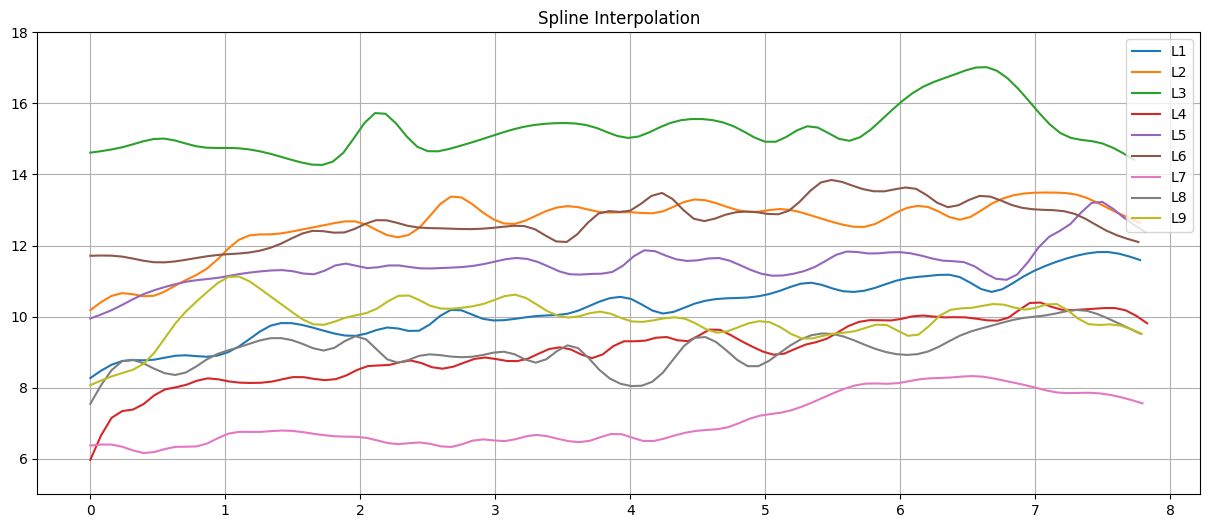

In [42]:
bases = {
    'L1': np.array([8.27, 8.737, 8.775, 8.911, 8.873, 9.184, 9.741, 9.776, 9.552, 9.477, 9.696, 9.614, 10.184, 9.96, 9.918, 10.024, 10.096, 10.43, 10.506, 10.094, 10.319, 10.504, 10.542, 10.728, 10.954, 10.729, 10.767, 11.04, 11.148, 11.108, 10.696, 11.072, 11.477, 11.737, 11.811, 11.591]),
    'L2': np.array([10.179, 10.655, 10.568, 10.95, 11.422, 12.185, 12.314, 12.44, 12.606, 12.65, 12.263, 12.525, 13.371, 12.986, 12.598, 12.896, 13.108, 12.94, 12.939, 12.938, 13.278, 13.153, 12.941, 13.026, 12.855, 12.604, 12.556, 12.981, 13.066, 12.726, 13.15, 13.448, 13.49, 13.405, 13.022, 12.638]),
    'L3': np.array([14.613, 14.794, 15.011, 14.781, 14.743, 14.581, 14.305, 14.575, 15.756, 14.845, 14.726, 15.03, 15.331, 15.444, 15.33, 15.027, 15.406, 15.559, 15.294, 14.91, 15.363, 14.946, 15.555, 16.389, 16.807, 16.997, 16.16, 15.133, 14.905, 14.411]),
    'L4': np.array([5.969, 7.203, 7.412, 7.881, 8.045, 8.256, 8.179, 8.132, 8.182, 8.306, 8.221, 8.303, 8.596, 8.638, 8.763, 8.552, 8.634, 8.845, 8.763, 8.805, 9.093, 9.053, 8.839, 9.262, 9.306, 9.432, 9.305, 9.644, 9.433, 9.096, 8.927, 9.183, 9.361, 9.736, 9.902, 9.899, 10.027, 9.982, 9.982, 9.898, 9.982, 10.406, 10.234, 10.192, 10.234, 10.191, 9.811]),
    'L5': np.array([9.947, 10.231, 10.594, 10.838, 11.003, 11.083, 11.204, 11.286, 11.285, 11.202, 11.488, 11.366, 11.446, 11.366, 11.367, 11.406, 11.528, 11.65, 11.487, 11.202, 11.202, 11.325, 11.853, 11.69, 11.568, 11.65, 11.407, 11.162, 11.204, 11.449, 11.816, 11.775, 11.815, 11.732, 11.57, 11.488, 11.08, 11.242, 12.139, 12.587, 13.238, 12.872, 12.383]),
    'L6': np.array([11.711, 11.688, 11.53, 11.597, 11.733, 11.802, 12.05, 12.413, 12.367, 12.713, 12.553, 12.484, 12.461, 12.527, 12.458, 12.1, 12.898, 12.981, 13.479, 12.754, 12.866, 12.935, 12.98, 13.772, 13.684, 13.524, 13.595, 13.078, 13.395, 13.144, 13.004, 12.889, 12.416, 12.099]),
    'L7': np.array([6.37, 6.371, 6.158, 6.328, 6.369, 6.709, 6.752, 6.795, 6.711, 6.626, 6.584, 6.413, 6.455, 6.328, 6.539, 6.497, 6.667, 6.539, 6.497, 6.709, 6.497, 6.631, 6.795, 6.88, 7.176, 7.304, 7.559, 7.898, 8.113, 8.113, 8.241, 8.282, 8.324, 8.198, 8.028, 7.857, 7.858, 7.772, 7.559]),
    'L8': np.array([7.545, 8.719, 8.588, 8.373, 8.853, 9.148, 9.391, 9.258, 9.071, 9.443, 8.746, 8.904, 8.877, 8.904, 8.984, 8.717, 9.198, 8.476, 8.048, 8.342, 9.332, 9.199, 8.587, 8.986, 9.466, 9.467, 9.146, 8.931, 9.039, 9.466, 9.733, 9.947, 10.054, 10.187, 9.92, 9.522]),
    'L9': np.array([8.07, 8.383, 8.756, 9.814, 10.61, 11.141, 10.769, 10.186, 9.761, 9.974, 10.186, 10.611, 10.292, 10.241, 10.399, 10.613, 10.191, 9.979, 10.139, 9.873, 9.923, 9.923, 9.553, 9.765, 9.818, 9.392, 9.498, 9.607, 9.768, 9.447, 10.089, 10.245, 10.354, 10.197, 10.354, 9.826, 9.779, 9.514])
}


plt.figure(figsize=(15, 6))
for experiment in bases.keys():

    # Define 10 data points
    x = np.array([i for i in np.arange(0, 8, 8/len(bases[experiment]))])
    y = np.array(bases[experiment])

    # Create a cubic spline object
    # bc_type='natural' applies natural boundary conditions (second derivative is zero at endpoints)
    spline_func = CubicSpline(x, y, bc_type='natural')

    # Generate new x values for a smoother plot of the spline
    x_new = np.linspace(x.min(), x.max(), 100)

    # Evaluate the spline at the new x values
    y_new = spline_func(x_new)

    plt.plot(x_new, y_new, label=experiment)
    plt.ylim((5, 18))
    plt.title('Spline Interpolation')

plt.legend(loc='upper right')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Bead width distribution')

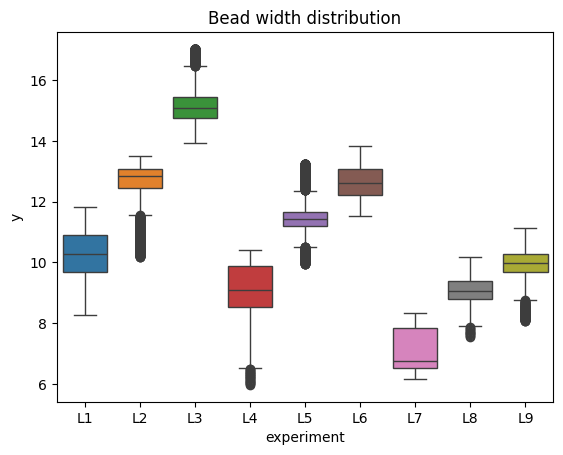

In [ ]:
static_df = raw_static_df.copy()
axis = sns.boxplot(static_df, y='y', x='experiment', hue='experiment')
axis.set_title("Bead width distribution")

#### Dataset with 50% of the data in the stable region

Text(0.5, 1.0, 'Bead width distribution')

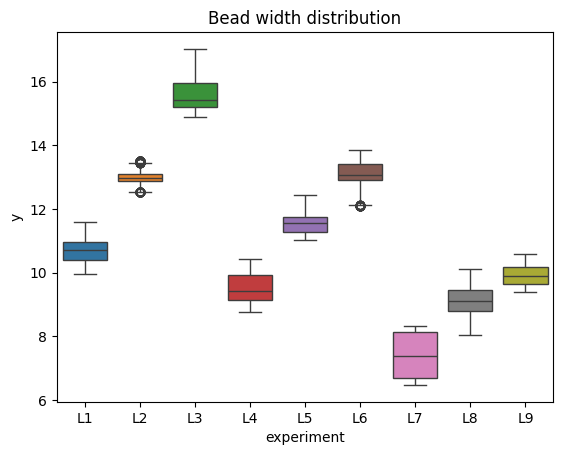

In [ ]:
static_df = raw_static_df.copy()

filtered_static_dfs = []

for e in static_df['experiment'].unique():
    experiment_df = static_df[static_df['experiment'] == e]
    lower_limit = int(np.ceil(experiment_df.shape[0] * 0.40))
    upper_limit = int(np.ceil(experiment_df.shape[0] * 0.90))
    filtered_experiment_df = experiment_df.iloc[lower_limit: upper_limit, :].copy()
    filtered_static_dfs.append(filtered_experiment_df)

static_df = pd.concat(filtered_static_dfs)

axis = sns.boxplot(static_df, y='y', x='experiment', hue='experiment')
axis.set_title("Bead width distribution")

## Classes separability

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


classification_df = static_df.copy()
classification_df = classification_df.drop(['current', 'nozzle_speed', 'mass_flow_rate', 'y'], axis=1)

classifier = RandomForestClassifier()
cv_scores = cross_val_score(estimator=classifier, X=classification_df.drop(['experiment'], axis=1), y=classification_df['experiment'], cv=5, scoring='accuracy')
cv_scores


array([0.96396396, 0.96771772, 0.96657905, 0.96657905, 0.96958318])

In [63]:
regression_df = static_df.copy()

results = {}

for e in regression_df['experiment'].unique():

    leave_one_out_train_df = regression_df[regression_df['experiment'] != e]
    x_train, x_val, y_train, y_val = train_test_split(leave_one_out_train_df.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), leave_one_out_train_df['y'], train_size=0.7, random_state=42)
    
    regressor = keras.Sequential([
        keras.layers.Input(shape=(1536,)),  # Input layer
        keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
        keras.layers.Dense(1)                  # Output layer with a single neuron (for regression)
    ])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        verbose=0,
        mode="auto",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0,
    )

    regressor.compile(optimizer='adam', loss='mean_absolute_error')
    regressor.fit(x_train, y_train, epochs=300, batch_size=128, validation_data=(x_val, y_val), callbacks=[early_stopping], verbose=0)


    leave_one_out_test_df = regression_df[regression_df['experiment'] == e]
    x_test = leave_one_out_test_df.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1)
    y_test = leave_one_out_test_df['y']
    y_pred = regressor.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results[e] = [mae, mape]
    print(f'{e} -> {mae}, {mape}')

results_df = pd.DataFrame(index=results.keys(), columns=['MAE', 'MAPE'], data=results.values())
results_df

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
L1 -> 0.9273917967963485, 0.08750841001209157
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
L2 -> 1.0540485162102171, 0.08100559317412583
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
L3 -> 3.260205986964052, 0.20727505168883087
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
L4 -> 1.144852813975392, 0.12163027587931687
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
L5 -> 0.9158703987508221, 0.07934435076603501
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
L6 -> 1.6816812184417658, 0.12769895975887444
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
L7 -> 2.3537993621172912, 0.3296915276022732
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
L8 -> 1.0648679511190562, 0.11919725036816631
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
L9 -> 1.5324226837531656, 0.15541247572948919


,MAE,MAPE
L1,0.927392,0.087508
L2,1.054049,0.081006
L3,3.260206,0.207275
L4,1.144853,0.121630
L5,0.915870,0.079344
L6,1.681681,0.127699
L7,2.353799,0.329692
L8,1.064868,0.119197
L9,1.532423,0.155412


In [65]:
temporal_dataset_path = "https://leofernanndes-datasets.s3.us-east-1.amazonaws.com/ded-pta/20251128/clean_stable_convolutional_features_100_df.csv"
raw_temporal_df = pd.read_csv(temporal_dataset_path)
raw_temporal_df

,0,1,2,3,4,5,6,7,8,9,...,1626,1627,1628,1629,1630,1631,1632,1633,1634,1635
0,0.632686,1.008760,0.921708,1.296683,2.240439,2.897286,2.349713,2.228437,2.425739,2.594367,...,10.436749,10.437054,10.437360,10.437668,10.437976,10.438284,10.438594,10.438905,10.439216,10.439529
1,1.536401,0.689486,1.067901,1.409488,2.038352,3.175830,4.637600,3.385772,1.997899,1.930754,...,10.436749,10.437054,10.437360,10.437668,10.437976,10.438284,10.438594,10.438905,10.439216,10.439529
2,1.233041,1.385923,0.676391,1.556173,3.731225,2.104127,1.040784,0.451536,1.895649,1.803357,...,10.436749,10.437054,10.437360,10.437668,10.437976,10.438284,10.438594,10.438905,10.439216,10.439529
3,1.723354,0.762727,1.587020,1.769352,1.348338,3.233941,2.077139,2.290675,1.315012,2.628616,...,10.436749,10.437054,10.437360,10.437668,10.437976,10.438284,10.438594,10.438905,10.439216,10.439529
4,0.400057,1.467532,2.073484,0.613505,1.856605,4.533729,1.558789,2.311662,2.851298,2.319255,...,10.436749,10.437054,10.437360,10.437668,10.437976,10.438284,10.438594,10.438905,10.439216,10.439529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17739,0.297504,0.915572,0.746224,1.659630,1.881812,3.026524,0.864984,2.037880,1.969931,0.767824,...,10.005634,10.171002,10.206891,10.200650,10.166722,10.066703,10.236674,10.118358,10.121484,10.222867
17740,1.429887,1.137751,0.473657,1.482403,2.021913,4.016655,0.717395,1.162370,2.675787,0.540656,...,10.165133,9.914406,10.081567,10.296645,10.153304,10.299815,10.085213,10.088180,10.141139,10.186294
17741,1.141399,1.734999,0.578553,0.413348,1.187700,2.951668,1.492679,1.073537,2.634356,0.759183,...,10.094330,10.189430,10.039653,10.129246,10.227543,10.139363,10.222894,10.097526,10.173800,10.177817
17742,0.970493,1.219518,0.356623,0.375329,1.093675,2.932173,0.760242,1.113714,2.026122,1.145206,...,10.095551,10.071053,10.157285,9.929981,10.201205,10.340101,10.208643,10.276944,10.021848,10.207019


In [67]:
regression_df = raw_temporal_df.copy()

results = {}

for e in regression_df['experiment'].unique():

    leave_one_out_train_df = regression_df[regression_df['experiment'] != e]
    x_train, x_val, y_train, y_val = train_test_split(leave_one_out_train_df.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1), leave_one_out_train_df['y'], train_size=0.7, random_state=42)
    
    regressor = keras.Sequential([
        keras.layers.Input(shape=(x_train.shape[1],)),  # Input layer
        keras.layers.Dense(32, activation='relu'),  # Hidden layer with 32 neurons and ReLU activation
        keras.layers.Dense(1)                  # Output layer with a single neuron (for regression)
    ])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        verbose=0,
        mode="auto",
        baseline=None,
        restore_best_weights=True,
        start_from_epoch=0,
    )

    regressor.compile(optimizer='adam', loss='mean_absolute_error')
    regressor.fit(x_train, y_train, epochs=300, batch_size=128, validation_data=(x_val, y_val), callbacks=[early_stopping], verbose=0)


    leave_one_out_test_df = regression_df[regression_df['experiment'] == e]
    x_test = leave_one_out_test_df.drop(['y', 'current', 'nozzle_speed', 'mass_flow_rate', 'experiment'], axis=1)
    y_test = leave_one_out_test_df['y']
    y_pred = regressor.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results[e] = [mae, mape]
    print(f'{e} -> {mae}, {mape}')

results_df = pd.DataFrame(index=results.keys(), columns=['MAE', 'MAPE'], data=results.values())
results_df

2026-04-06 01:14:33.575687: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 4 bytes spill stores, 4 bytes spill loads

2026-04-06 01:14:33.963667: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 4 bytes spill stores, 4 bytes spill loads

2026-04-06 01:14:34.381400: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 4 bytes spill stores, 4 bytes spill loads



 1/90 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step

2026-04-06 01:14:50.391350: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 4 bytes spill stores, 4 bytes spill loads



90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
L1 -> 0.31517151317577485, 0.030246259439965253
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
L2 -> 0.22798438142479224, 0.017596734767360477
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
L3 -> 0.37376734553150426, 0.02384574625896744
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
L4 -> 0.33555230927330687, 0.03541126087065251
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
L5 -> 0.19492207467574588, 0.01688798420337841
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
L6 -> 0.26046137699333044, 0.020151521050185858
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
L7 -> 0.4800815868355608, 0.061727703392602216


2026-04-06 01:16:35.766919: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 4 bytes spill stores, 4 bytes spill loads



38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
L8 -> 0.32621101629842786, 0.035995633296589516
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
L9 -> 0.22887803387288652, 0.022685271646238903


,MAE,MAPE
L1,0.315172,0.030246
L2,0.227984,0.017597
L3,0.373767,0.023846
L4,0.335552,0.035411
L5,0.194922,0.016888
L6,0.260461,0.020152
L7,0.480082,0.061728
L8,0.326211,0.035996
L9,0.228878,0.022685
